In [1]:
import sys
import os
sys.path.append(os.path.abspath("../clean_code/"))
sys.path

['/Users/yoavfreund/opt/anaconda3/lib/python3.8/site-packages/,/Users/yoavfreund/python_packages',
 '',
 '/usr/local/lib/python2.7/site-packages',
 '/usr/local/Caskroom/miniforge/base/envs/faiss_env/lib/python39.zip',
 '/usr/local/Caskroom/miniforge/base/envs/faiss_env/lib/python3.9',
 '/usr/local/Caskroom/miniforge/base/envs/faiss_env/lib/python3.9/lib-dynload',
 '/usr/local/Caskroom/miniforge/base/envs/faiss_env/lib/python3.9/site-packages',
 '/Users/yoavfreund/projects/VoltageDimentionalReduction/clean_code']

In [2]:
%cd ../clean_code/

/Users/yoavfreund/projects/VoltageDimentionalReduction/clean_code


In [3]:
from Visualization import generalVisualization
from Visualization import mnistVisuals
from Visualization import visualHelpers
from Visualization.mnistVisuals import plot_landmark_subset
from Utilities import config
import pickle
import select_landmarks_MI
import importlib
import voltagemap
import main
import matplotlib.pyplot as plt
import numpy as np

In [4]:

#load data from the pickle file
with open('../../Voltage_Temp/Results/mnist/saved_data.pkl', 'rb') as f:
    data= pickle.load(f)


In [5]:

data.keys()


dict_keys(['majority_labels', 'label_counts', 'all_voltages', 'centroids', 'voltage_map'])

In [6]:

voltages= data['voltage_map']
centroids= data['centroids']


label_counts= data['label_counts']
label_counts[1].most_common()[0][1]
!ls -l ../../Voltage_Temp/Scatter_Plots/

total 0
drwxr-xr-x  12 yoavfreund  staff  384 Aug 23 15:07 glove
drwxr-xr-x@  5 yoavfreund  staff  160 Jul 23 13:08 glove2000
drwxr-xr-x@  8 yoavfreund  staff  256 Aug 23 15:48 mnist
drwxr-xr-x   2 yoavfreund  staff   64 Aug 24 12:45 mnist7,10,14,15,16


Number of points with no label: 343
Plot saved to ../../Voltage_Temp/Scatter_Plots/mnist/0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19.png


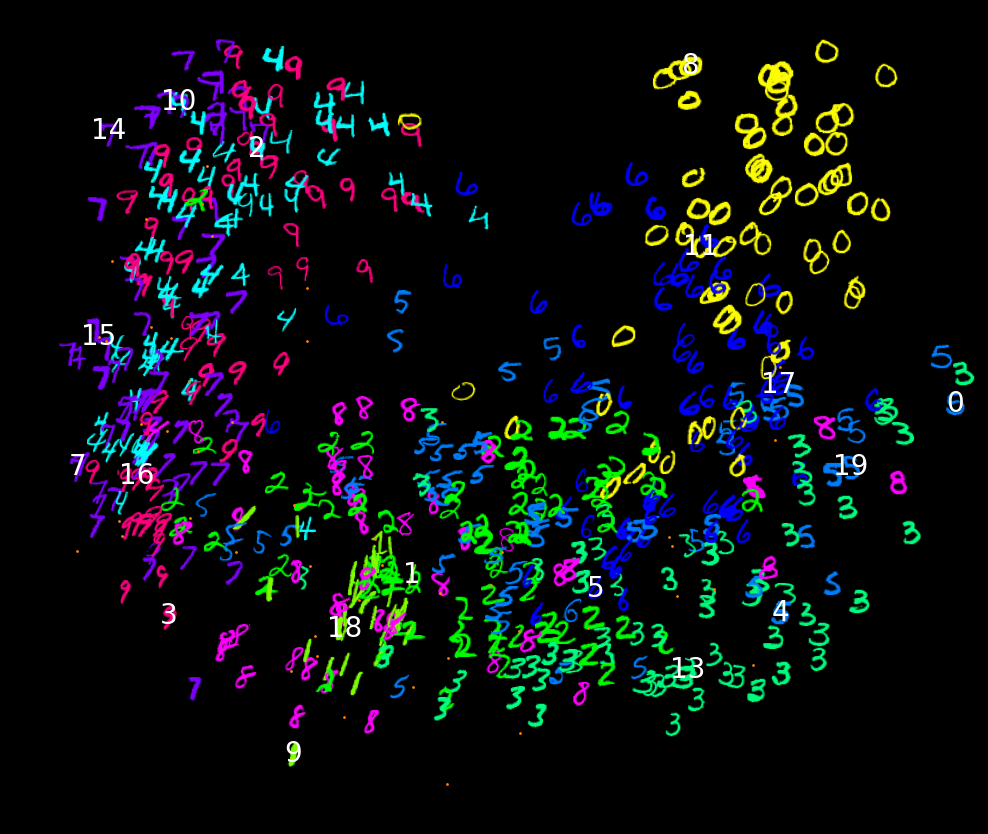

In [8]:
focus_on = np.array(range(20))
#focus_on = np.array([7,10,14,15,16])
#focus_on = np.array([1,9,18])
#focus_on = np.array([1,3,9,18])

"""
Visualizes MNIST digits in 2D space using voltage-based embeddings reduced by PCA or MDS.

Each point in the embedding is rendered as a translucent RGB digit image colored by its label.
Landmark points (voltage = 1) are optionally scaled up to highlight their influence.

"""

transformation="pca"; landmarkSize=3; alpha_actual=1; percent_size=0.02; out_file=None; log_transform=True; num_labels=10

points = voltages.voltage_array()

transformed_points = visualHelpers.transform(points, "pca")

plots_dir='../../Voltage_Temp/Scatter_Plots/mnist/'
','.join([str(x) for x in list(focus_on)])
out_plot=plots_dir+','.join([str(x) for x in list(focus_on)])+'.png'


from Visualization.mnistVisuals import plot_landmark_subset

plot_landmark_subset(points, centroids, label_counts, focus_on, percent_size=percent_size, 
                     alpha_actual=alpha_actual, out_file=out_plot,element='digit')



In [9]:
centroids.shape, points.shape

((1000, 784), (1000, 20))